# Pronóstico de Ventas en Supermercados mediante un Modelo Global LightGBM

## Resumen

Este notebook implementa un pipeline de pronóstico de series temporales para predecir las ventas diarias de una cadena de supermercados ecuatoriana (dataset *Corporación Favorita*). Se entrenan 1 782 series de forma simultánea mediante un modelo global basado en LightGBM con características de rezago (*lags*), medias móviles y variables exógenas (feriados, precio del petróleo, información de tienda). El desempeño se evalúa con validación cruzada temporal utilizando la métrica RMSLE y se compara contra modelos estadísticos de referencia (Seasonal Naïve, AutoETS).

## Objetivos

- Construir un modelo global de pronóstico de series temporales capaz de predecir ventas a 16 días para múltiples combinaciones tienda–familia de producto.
- Evaluar el desempeño del modelo LightGBM frente a líneas base estadísticas mediante validación cruzada temporal.
- Exportar el modelo entrenado a formato ONNX para su despliegue en un servicio de inferencia en producción.

## Estructura del documento

El documento se organiza en las siguientes secciones: (1) Carga de datos y análisis exploratorio, (2) Ingeniería de características, (3) Preprocesamiento de feriados, (4) Entrenamiento y validación cruzada — incluyendo modelos de referencia y el modelo LightGBM —, (5) Exportación a ONNX, (6) Modelo final y generación de predicciones, y (7) Generación del archivo de envío.


## 1. Entorno y Dependencias

A continuación se instalan las bibliotecas requeridas y se importan los módulos necesarios para el pipeline de pronóstico.


In [6]:
!pip install utilsforecast mlforecast lightgbm statsforecast seaborn -q

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from utilsforecast.plotting import plot_series

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences, LocalStandardScaler
from mlforecast.lag_transforms import ExpandingMean, RollingMean
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from datetime import datetime


import logging

logging.basicConfig(level=logging.INFO)

sns.set_style("whitegrid")

## 2. Carga de Datos y Análisis Exploratorio Inicial

El dataset *Corporación Favorita* está compuesto por múltiples archivos que contienen registros históricos de ventas diarias, transacciones por tienda, información de feriados nacionales y regionales, precios del petróleo (variable macroeconómica relevante en la economía ecuatoriana) y metadatos de las tiendas (ciudad, estado, tipo y clúster). La granularidad de las ventas está definida por la combinación tienda–familia de producto, lo que da lugar a 1 782 series temporales individuales que el modelo debe pronosticar de forma simultánea. Esta estructura jerárquica multi-serie constituye el principal desafío del problema, ya que exige un enfoque de modelado que pueda capturar patrones compartidos entre series sin perder la especificidad de cada una.

A continuación se cargan todos los archivos fuente y se inspecciona la dimensionalidad del conjunto de datos.


In [8]:
# load train, test datasets
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
trans = pd.read_csv("../data/transactions.csv")
holidays = pd.read_csv("../data/holidays_events.csv")
stores = pd.read_csv("../data/stores.csv")
oil = pd.read_csv("../data/oil.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")

In [9]:
unique_ts = train.groupby(['store_nbr', 'family']).ngroups
print(f"Number of unique timeseries to forecast: {unique_ts}")
train.sort_values(["store_nbr","family","date"])

Number of unique timeseries to forecast: 1782


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0
...,...,...,...,...,...,...
2993627,2993627,2017-08-11,54,SEAFOOD,0.0,0
2995409,2995409,2017-08-12,54,SEAFOOD,1.0,1
2997191,2997191,2017-08-13,54,SEAFOOD,2.0,0
2998973,2998973,2017-08-14,54,SEAFOOD,0.0,0


## 3. Ingeniería de Características

La ingeniería de características (*feature engineering*) transforma los datos crudos en representaciones más informativas para el modelo predictivo. En el contexto de series temporales, esta etapa resulta especialmente crítica porque los algoritmos de aprendizaje supervisado como LightGBM no poseen una noción intrínseca de orden temporal; dicha información debe codificarse explícitamente a través de características derivadas. En este trabajo se realizan las siguientes transformaciones: (a) creación de un identificador único por serie (`unique_id`) a partir de la combinación tienda–familia, (b) limpieza de valores negativos y sustitución de ceros en ventas, (c) codificación numérica de variables categóricas (familia de producto, tipo de tienda, ciudad, clúster), y (d) construcción de una grilla temporal completa que garantiza la continuidad de cada serie para el cálculo posterior de rezagos.

A continuación se definen las funciones de preparación de datos y se generan los conjuntos de entrenamiento con y sin variables exógenas.


In [10]:
def create_unique_id(df):
    """Create unique_id based on store_nbr and family grouping."""
    df = df.copy()
    df['unique_id'] = df.groupby(['store_nbr', 'family']).ngroup()
    return df

def rename_for_mlforecast(df):
    """Rename columns to standard forecasting format (ds, y)."""
    return df.rename(columns={
        "date": "ds",
        "sales": "y"
    })



In [11]:

def clean_sales_data(df):
    """Clean sales data by ensuring no negative values and replacing zeros."""
    df = df.copy()
    if 'sales' in df.columns:
        df['sales'] = np.maximum(df['sales'], 0)  # Ensure no negative sales
        df['sales'] = df['sales'].replace(0, 0.01)
    return df

def encode_categorical_features(df, categorical_cols, factors=None):
    """
    Encode categorical columns. If factors provided, use them; otherwise create new ones.
    """
    df = df.copy()

    if factors is None:
        # Training mode: create new factors
        factors = {}
        for col in categorical_cols:
            if col in df.columns:
                labels, uniques = pd.factorize(df[col])
                factors[col] = dict(zip(uniques, labels))  # Store the mapping
                df[col] = labels
    else:
        # Test mode: use existing factors
        for col in categorical_cols:
            if col in df.columns and col in factors:
                df[col] = df[col].map(factors[col]).fillna(-1)

    return df, factors

def create_complete_time_grid(df):
    """Create a complete time grid for all unique_ids across the full date range."""
    date_range = pd.date_range(df.ds.min(), df.ds.max())
    complete_grid = pd.MultiIndex.from_product(
        [df.unique_id.unique(), date_range],
        names=['unique_id', 'ds']
    ).to_frame(index=False)

    # Merge with original data and fill missing values
    df_filled = complete_grid.merge(df, how='left', on=['unique_id', 'ds'])
    return df_filled.fillna(0)

def prepare_base_data(df):
    """Apply common data preparation steps."""
    df = create_unique_id(df)
    df = clean_sales_data(df)
    df["date"] = pd.to_datetime(df.date)
    df = rename_for_mlforecast(df)
    return df

def prepare_train(t):
    """Prepare training data without exogenous variables."""
    X = prepare_base_data(t)
    X = X[["y", "ds", "unique_id"]]
    X_filled = create_complete_time_grid(X)
    return X_filled

def prepare_train_with_exog(t):
    """Prepare training data with exogenous variables."""
    X = prepare_base_data(t)
    exog_cols = ["y", "ds", "unique_id", "onpromotion", "family", 'store_nbr']
    X = X[exog_cols]
    X, factors = encode_categorical_features(X, ["family"])
    X_filled = create_complete_time_grid(X)
    return X_filled, factors

def prepare_test_with_exog(t):
    """Prepare test data with exogenous variables."""
    X = prepare_base_data(t)
    # since we are providing a unique_id, the mlforecast lib will automatically replicate family & store_nbr
    exog_cols = ["ds", "unique_id", "onpromotion"]
    if 'y' in X.columns:
        exog_cols.insert(0, "y")
    X = X[exog_cols]
    return X

def create_complete_date_range(df, date_col):
    """Create a complete date range from min to max date in the dataframe."""
    return pd.date_range(df[date_col].min(), df[date_col].max(), freq='D')

def fill_missing_dates(df, date_col, fill_cols=None):
    """Fill missing dates in a time series dataframe."""
    df = df.copy()
    complete_dates = create_complete_date_range(df, date_col)
    complete_df = pd.DataFrame({date_col: complete_dates})
    df_filled = complete_df.merge(df, on=date_col, how='left')
    return df_filled

def prepare_holidays(hols):
    hols["date"] = pd.to_datetime(hols.date)
    return hols

In [12]:
X_train = prepare_train(train)
X_train_exog, factors = prepare_train_with_exog(train)

X_train_exog.head()

,unique_id,ds,y,onpromotion,family,store_nbr
0,0,2013-01-01,0.01,0.0,0.0,1.0
1,0,2013-01-02,2.00,0.0,0.0,1.0
2,0,2013-01-03,3.00,0.0,0.0,1.0
3,0,2013-01-04,3.00,0.0,0.0,1.0
4,0,2013-01-05,5.00,0.0,0.0,1.0


## 4. Preprocesamiento de Feriados

Los feriados constituyen una fuente fundamental de variabilidad exógena en datos de ventas minoristas, dado que generan picos o caídas de demanda que no pueden explicarse únicamente por patrones estacionales regulares. Sin embargo, no todos los feriados del calendario tienen un impacto estadísticamente relevante sobre las ventas. Para evitar la introducción de ruido y la dilución de señal en el modelo, se aplica un filtro basado en la correlación de Pearson entre un indicador binario de cada feriado y el volumen de ventas agregado. Solo se retienen aquellos feriados cuya correlación absoluta supera un umbral de 0.1, valor seleccionado mediante validación cruzada sobre varios puntos de corte. Los feriados seleccionados se codifican como variables *dummy* (one-hot) y se incorporan al conjunto de datos de entrenamiento.

A continuación se procesan los feriados, se calculan las correlaciones y se incorporan al dataset las variables indicadoras correspondientes.


In [13]:
holidays_clean = prepare_holidays(holidays)
print(f"Number of holidays: {holidays_clean.description.nunique()}")
holidays_clean.head()

Number of holidays: 103


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [14]:
def get_selected_hols(df):
    """Calculates correlations between holidays and sales, used for filtering out redundent hols from model features"""
    correlations = {}

    for holiday in df['description'].unique():
        holiday_indicator = (df['description'] == holiday).astype(int)

        correlation = np.corrcoef(holiday_indicator, df['y'])[0, 1]
        correlations[holiday] = correlation

    corr_df = pd.DataFrame(list(correlations.items()), columns=['holiday', 'sales_correlation'])
    corr_df = corr_df.sort_values('sales_correlation', ascending=False)
    selected_holidays = corr_df.loc[abs(corr_df.sales_correlation) > 0.1 ] # the 0.1 threhsold got the best scores after corssvalidating a few cutoffs
    return selected_holidays

hol_sales = pd.merge(X_train, holidays_clean, left_on="ds", right_on="date").query('transferred == False')
plt_df = hol_sales.groupby(["description", "date", "locale"])["y"].sum().reset_index()
selected_hols = get_selected_hols(plt_df)
selected_hols

,holiday,sales_correlation
47,Navidad-2,0.168884
100,Traslado Primer dia del ano,0.152953
77,Terremoto Manabi+2,0.140734
49,Navidad-4,0.131879
48,Navidad-3,0.130318
9,Cantonizacion de Salinas,0.130318
66,Terremoto Manabi+1,0.124679
72,Terremoto Manabi+15,0.124308
46,Navidad-1,0.123238
51,Primer dia del ano,-0.299127


In [15]:
def add_holidays_vars(X, hols, selected_hols):
    hols["description"] = hols.description.str.replace(r'[.!?,:;"]', '', regex=True)
    merge_hols = pd.get_dummies(hols.loc[(hols.description.isin(selected_hols.holiday)) & (hols.transferred == False)][["date", "description"]])
    merge_hols = merge_hols.drop_duplicates(subset="date")
    X_hols = pd.merge(X, merge_hols, how="left", right_on="date", left_on="ds").drop(columns="date")
    X_hols = X_hols.fillna(0) # days without hols will have nan hol vars
    for col in X_hols.columns:
        if col not in ["ds", "y", "unique_id", "family", "store_nbr", "oil", "store_cluster"]:
            X_hols[col] = X_hols[col].astype("int8")

    X_hols.columns = X_hols.columns.str.replace(" ", "_")
    return X_hols


X_train_holidays = add_holidays_vars(X_train_exog, holidays_clean, selected_hols)
X_train_holidays.head()

,unique_id,ds,y,onpromotion,family,store_nbr,description_Cantonizacion_de_Salinas,description_Navidad,description_Navidad-1,description_Navidad-2,description_Navidad-3,description_Navidad-4,description_Primer_dia_del_ano,description_Terremoto_Manabi+1,description_Terremoto_Manabi+15,description_Terremoto_Manabi+2,description_Traslado_Primer_dia_del_ano
0,0,2013-01-01,0.01,0,0.0,1.0,0,0,0,0,0,0,1,0,0,0,0
1,0,2013-01-02,2.00,0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0
2,0,2013-01-03,3.00,0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0
3,0,2013-01-04,3.00,0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0
4,0,2013-01-05,5.00,0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0


## 5. Entrenamiento y Validación Cruzada

La evaluación del desempeño predictivo se realiza mediante validación cruzada temporal (*time-series cross-validation*), un esquema que respeta el orden cronológico de las observaciones y evita la fuga de información (*data leakage*). Se definen 5 ventanas de evaluación con un horizonte de predicción de 16 días y un paso entre ventanas de 120 días. Para reducir el costo computacional durante la etapa de experimentación, la validación se ejecuta sobre un subconjunto aleatorio de 100 series (de las 1 782 totales), seleccionadas con semilla fija para garantizar reproducibilidad. La métrica de evaluación es el RMSLE (*Root Mean Squared Logarithmic Error*), que penaliza de forma más equilibrada los errores en series de distinta magnitud al operar en escala logarítmica.

A continuación se define la métrica RMSLE y la configuración de la validación cruzada.


In [17]:

def calculate_rmsle(df, actual_col='actual', predicted_col='predicted'):
    """
    Calculate Root Mean Squared Logarithmic Error (RMSLE) across all forecasts in a DataFrame.

    Parameters:
    - df: pandas DataFrame containing the forecast data aggregated by unique_id
    - actual_col: name of the column with actual values
    - predicted_col: name of the column with predicted values

    Returns:
    - RMSLE value calculated across all forecasts
    """
    actual = np.array(df[actual_col])
    predicted = np.array(df[predicted_col])

    # handle cases where values might be negative (clip at 0)
    actual = np.clip(actual, 0, None)
    predicted = np.clip(predicted, 0, None)

    log_actual = np.log1p(actual)       # log1p calculates log(1 + x) more accurately for small x
    log_predicted = np.log1p(predicted)

    # apply formula
    squared_log_errors = (log_predicted - log_actual) ** 2
    msle = np.mean(squared_log_errors)
    rmsle = np.sqrt(msle)

    return rmsle



In [18]:
# define cross validation data
subset = 100
X_dataset = X_train
np.random.seed(42)
rand_sub_index = np.random.randint(1, X_dataset.unique_id.nunique(), subset)
x_sub_small = X_dataset[X_dataset['unique_id'].isin(X_dataset['unique_id'].unique()[rand_sub_index])].copy()
horizon = 16
windows = 5
stepsize_days = 120

### 5.1. Modelos Estadísticos de Referencia (*Baseline*)

Como punto de comparación se entrenan dos modelos estadísticos clásicos: **Seasonal Naïve**, que utiliza como pronóstico el valor observado en el mismo día de la semana anterior (estacionalidad semanal, *s* = 7), y **AutoETS** (*Error, Trend, Seasonality*), que selecciona automáticamente la mejor combinación de componentes aditivos o multiplicativos para error, tendencia y estacionalidad. Estos modelos proporcionan una línea base contra la cual cuantificar la ganancia predictiva del modelo de *machine learning*.

A continuación se configuran, entrenan y evalúan los modelos de referencia.


In [19]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, Holt, AutoETS

# define models
s_len = 7 # weekly seasonality, common in retail data
models = [
    SeasonalNaive(season_length=s_len),
   AutoETS(season_length=s_len),
]

sf = StatsForecast(
    models=models,
    freq='D',  # daily frequency
    n_jobs=-1,
)


C:\Users\juana\PycharmProjects\tesis-umpe-supermarket-stock-prediction\.venv\Lib\site-packages\fs\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
C:\Users\juana\PycharmProjects\tesis-umpe-supermarket-stock-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
cv_results_baseline = sf.cross_validation(
    df=x_sub_small,
    h=horizon,
    step_size=stepsize_days,
    n_windows=windows,
)
cv_path_baseline = "cv_results_baseline_retrained.csv"
cv_results_baseline.to_csv(cv_path_baseline, index=False)

print(f"AutoETS CV RMSLE:         {calculate_rmsle(cv_results_baseline, actual_col='y', predicted_col='AutoETS'):.4}")
print(f"SeasonalNaive CV RMSLE:   {calculate_rmsle(cv_results_baseline, actual_col='y', predicted_col='SeasonalNaive'):.4}")

AutoETS CV RMSLE:         0.5814
SeasonalNaive CV RMSLE:   0.6852


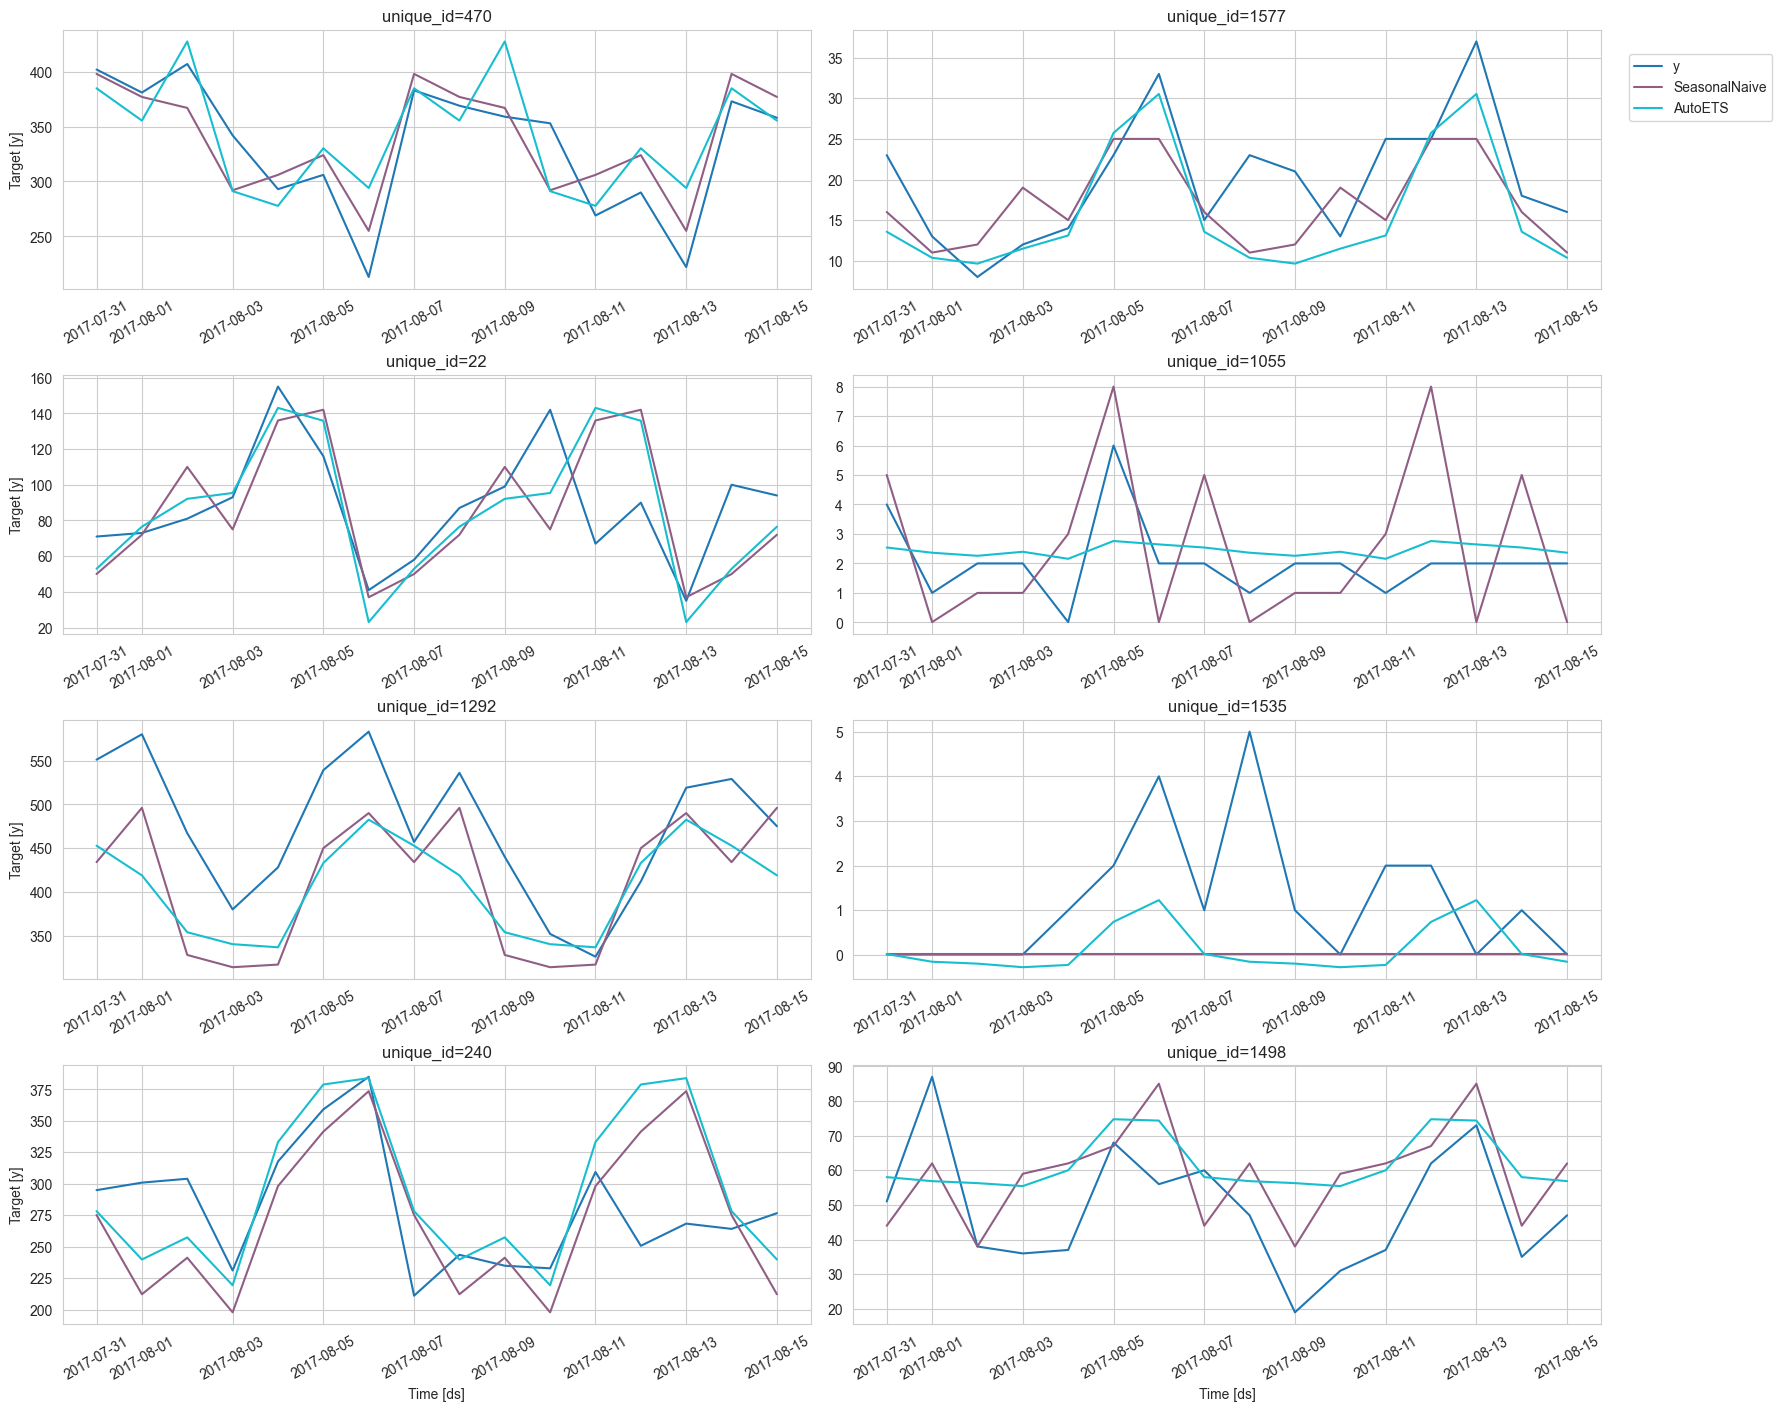

In [21]:
cutoffs = cv_results_baseline.cutoff.unique()
fig = plot_series(forecasts_df=cv_results_baseline.query("cutoff == @cutoffs[-1]").drop(columns='cutoff'))
fig

### 5.2. Modelo Global Recursivo LightGBM

El enfoque principal de este trabajo es un modelo global (*global forecasting model*) basado en LightGBM, un algoritmo de *gradient boosting* sobre árboles de decisión que utiliza técnicas de histograma para acelerar el entrenamiento. A diferencia de los modelos locales que ajustan parámetros independientes para cada serie, el modelo global aprende una única función de pronóstico alimentada por todas las series simultáneamente, lo que le permite capturar patrones cruzados y generalizar mejor en series con historial limitado. La predicción se realiza de forma recursiva: para generar el pronóstico en *t + h*, se utilizan los valores predichos en pasos anteriores como entrada para los rezagos. Las características del modelo incluyen: rezagos en los días 1, 7, 14, 28, 90 y 365; medias móviles (*rolling mean*) con ventanas de 7, 28 y 365 días; media expandida (*expanding mean*); normalización local por serie (*LocalStandardScaler*); y variables de calendario (día de la semana, inicio/fin de mes). Las variables estáticas tienda y familia de producto se incorporan para que el modelo diferencie el comportamiento de cada serie.

A continuación se configura el modelo, se inspeccionan las características generadas automáticamente y se ejecuta la validación cruzada.


In [22]:
mlf = MLForecast(
    models=[lgb.LGBMRegressor()],
    freq="d",
    lags=[1, 7, 14, 28, 90, 365],
    target_transforms=[LocalStandardScaler()],
    lag_transforms={
        1: [ExpandingMean()],
        7: [RollingMean(window_size=7), RollingMean(window_size=28), RollingMean(window_size=365)],
        28: [RollingMean(window_size=7), RollingMean(window_size=28), RollingMean(window_size=365)]
    },
    date_features=["day_of_week", "is_month_end", "is_month_start"],
)
X_dataset = X_train_holidays
x_sub_small_hols = X_dataset[X_dataset['unique_id'].isin(X_dataset['unique_id'].unique()[rand_sub_index])].copy()


In [23]:
# we have to fit a model before we can display our generated features
static_vars = ["store_nbr", "family"]
mlf.fit(x_sub_small_hols, static_features=static_vars)

# preprocess to show the generated features
preprocessed_features = mlf.preprocess(x_sub_small_hols, static_features=static_vars)

print("\nExample of generated features:")
print(preprocessed_features.info())
preprocessed_features.head()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006993 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3550
[LightGBM] [Info] Number of data points in the train set: 125712, number of used features: 30
[LightGBM] [Info] Start training from score 0.124955

Example of generated features:
<class 'pandas.core.frame.DataFrame'>
Index: 125712 entries, 24024 to 2913487
Data columns (total 33 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   unique_id                                125712 non-null  int64         
 1   ds                                       125712 non-null  datetime64[ns]
 2   y                                        125712 non-null  float64       
 3   onpromotion                              125712 non-nul

,unique_id,ds,y,onpromotion,family,store_nbr,description_Cantonizacion_de_Salinas,description_Navidad,description_Navidad-1,description_Navidad-2,...,expanding_mean_lag1,rolling_mean_lag7_window_size7,rolling_mean_lag7_window_size28,rolling_mean_lag7_window_size365,rolling_mean_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_mean_lag28_window_size365,day_of_week,is_month_end,is_month_start
24024,14,2014-01-28,0.239716,0,14.0,1.0,0,0,0,0,...,-0.058491,0.753062,0.369120,-0.080648,-0.355630,-0.184799,-0.098635,1,False,False
24025,14,2014-01-29,0.837623,0,14.0,1.0,0,0,0,0,...,-0.057732,0.753062,0.411828,-0.080648,-0.354775,-0.184799,-0.098635,2,False,False
24026,14,2014-01-30,-0.358192,0,14.0,1.0,0,0,0,0,...,-0.055460,0.496816,0.432968,-0.085563,-0.099383,-0.142091,-0.098635,3,False,False
24027,14,2014-01-31,2.033439,0,14.0,1.0,0,0,0,0,...,-0.056226,0.156009,0.347766,-0.088822,-0.013968,-0.035535,-0.092082,4,True,False
24028,14,2014-02-01,2.033439,0,14.0,1.0,0,0,0,0,...,-0.050949,0.325985,0.390260,-0.085563,0.156009,-0.014182,-0.100273,5,False,True


In [29]:
cv_results_lgbm = mlf.cross_validation(
    df=x_sub_small_hols,
    h=horizon,
    step_size=stepsize_days,
    n_windows=windows,
    static_features=static_vars,
)
print(f"\nLGBM RMSLE: {calculate_rmsle(cv_results_lgbm, actual_col="y", predicted_col='LGBMRegressor')}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002677 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3511
[LightGBM] [Info] Number of data points in the train set: 77600, number of used features: 26
[LightGBM] [Info] Start training from score 0.150670
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3526
[LightGBM] [Info] Number of data points in the train set: 89240, number of used features: 29
[LightGBM] [Info] Start training from score 0.141240
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

## 6. Exportación del Modelo a Formato ONNX

Para desplegar el modelo en un entorno de producción independiente de Python, se convierte el modelo LightGBM entrenado al formato ONNX (*Open Neural Network Exchange*). ONNX es un estándar abierto de representación de modelos de *machine learning* que permite ejecutar inferencia mediante *runtimes* optimizados (como ONNX Runtime) en múltiples plataformas y lenguajes. Esto posibilita integrar el modelo de pronóstico en el servidor de la aplicación web sin depender de la biblioteca LightGBM en tiempo de ejecución. La conversión preserva la estructura de árboles del modelo y requiere especificar el tipo de tensor de entrada con las dimensiones correctas.

A continuación se instalan las dependencias de conversión, se exporta el modelo y se verifica la inferencia con ONNX Runtime.


In [24]:
!pip install onnxmltools onnxruntime -q

In [25]:
import onnxmltools
from onnxmltools.convert.lightgbm.operator_converters.LightGbm import convert_lightgbm
from onnxmltools.convert.common.data_types import FloatTensorType

# 1. Get the LightGBM model from MLForecast
lgb_model = mlf.models_['LGBMRegressor']

# 2. Define the input type for the ONNX model
# The number of features must match the input size of the model
initial_types = [('input', FloatTensorType([None, lgb_model.n_features_]))]

# 3. Convert the model
onnx_model = onnxmltools.convert_lightgbm(lgb_model, initial_types=initial_types)

# 4. Save the model
onnx_filename = "../server/models/lightgbm_model.onnx"
onnxmltools.utils.save_model(onnx_model, onnx_filename)

print(f"Model exported to {onnx_filename}")

Model exported to lightgbm_model.onnx


In [26]:
print(lgb_model.feature_name_)

['onpromotion', 'family', 'store_nbr', 'description_Cantonizacion_de_Salinas', 'description_Navidad', 'description_Navidad-1', 'description_Navidad-2', 'description_Navidad-3', 'description_Navidad-4', 'description_Primer_dia_del_ano', 'description_Terremoto_Manabi+1', 'description_Terremoto_Manabi+15', 'description_Terremoto_Manabi+2', 'description_Traslado_Primer_dia_del_ano', 'lag1', 'lag7', 'lag14', 'lag28', 'lag90', 'lag365', 'expanding_mean_lag1', 'rolling_mean_lag7_window_size7', 'rolling_mean_lag7_window_size28', 'rolling_mean_lag7_window_size365', 'rolling_mean_lag28_window_size7', 'rolling_mean_lag28_window_size28', 'rolling_mean_lag28_window_size365', 'day_of_week', 'is_month_end', 'is_month_start']


In [27]:
import onnxruntime as rt
import numpy as np
import pandas as pd

# Load the ONNX model
sess = rt.InferenceSession(onnx_filename)

# Get input name
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name

# Generate valid input features using MLForecast's preprocessing
# We pick a sample from training data to ensure we have enough history to generate lags
# We need a specific unique_id to generate lags for that series
uid = X_train_holidays['unique_id'].unique()[0]
# We select enough history (max lag is 365, so we need > 365 rows)
sample_data = X_train_holidays[X_train_holidays['unique_id'] == uid].tail(400)

# Preprocess generates the lag features based on the model's configuration
# static_features must match what was used in fit()
features_df = mlf.preprocess(sample_data, static_features=['store_nbr', 'family'], dropna=True)

if features_df.empty:
    print("Not enough data in sample to generate features (check lag sizes).")
else:
    # Ensure correct column order using the model's feature names
    # The ONNX model expects features in the exact order they were trained on
    feature_cols = mlf.ts.features_order_

    # Get the first valid row
    input_row = features_df[feature_cols].iloc[[0]]
    dummy_input = input_row.to_numpy().astype(np.float32)

    print(f"Input shape: {dummy_input.shape}")

    # Run prediction
    pred_onnx = sess.run([label_name], {input_name: dummy_input})[0]

    print(f"ONNX Prediction for sample row: {pred_onnx[0]}")

Input shape: (1, 30)
ONNX Prediction for sample row: [0.26465625]


## 7. Entrenamiento del Modelo Final y Generación de Predicciones

Una vez validada la configuración del modelo mediante validación cruzada, se procede al entrenamiento final utilizando la totalidad del conjunto de entrenamiento (todas las 1 782 series). El modelo final emplea la misma configuración de hiperparámetros y características que la versión validada, con el objetivo de maximizar la cantidad de datos históricos disponibles para el aprendizaje. Tras el entrenamiento, se genera el pronóstico a 16 días sobre el conjunto de prueba, se analiza la importancia de las características (*feature importance*) y se aplica un *clipping* inferior a cero para garantizar que las predicciones de ventas sean no negativas.

A continuación se entrena el modelo final, se inspeccionan las características más relevantes y se generan las predicciones.


In [30]:
# Configuracion final del modelo con las caracteristicas validadas en CV
mlf = MLForecast(
    models=[lgb.LGBMRegressor()],
    freq="d",
    lags=[1, 7, 14, 28, 90, 365],
    target_transforms=[LocalStandardScaler()],
    lag_transforms={
        1: [ExpandingMean()],
        7: [RollingMean(window_size=7), RollingMean(window_size=28), RollingMean(window_size=365)],
        28: [RollingMean(window_size=7), RollingMean(window_size=28), RollingMean(window_size=365)]
    },
    date_features=["day_of_week", "is_month_end", "is_month_start"],
)


In [31]:
print("static_vars during training:", static_vars)
mlf.fit(X_train_holidays, static_features=static_vars)

static_vars during training: ['store_nbr', 'family']
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3566
[LightGBM] [Info] Number of data points in the train set: 2309472, number of used features: 30
[LightGBM] [Info] Start training from score 0.132607


MLForecast(models=[LGBMRegressor], freq=d, lag_features=['lag1', 'lag7', 'lag14', 'lag28', 'lag90', 'lag365', 'expanding_mean_lag1', 'rolling_mean_lag7_window_size7', 'rolling_mean_lag7_window_size28', 'rolling_mean_lag7_window_size365', 'rolling_mean_lag28_window_size7', 'rolling_mean_lag28_window_size28', 'rolling_mean_lag28_window_size365'], date_features=['day_of_week', 'is_month_end', 'is_month_start'], num_threads=1)

In [32]:
model = mlf.models_['LGBMRegressor']
feature_importance = model.feature_importances_
feature_names = mlf.ts.features_order_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
importance_df.head(10)

,feature,importance
14,lag1,375
1,family,320
15,lag7,265
27,day_of_week,234
0,onpromotion,189
19,lag365,155
2,store_nbr,154
16,lag14,147
17,lag28,132
21,rolling_mean_lag7_window_size7,131


In [33]:
X_test_holidays = add_holidays_vars(prepare_test_with_exog(test), holidays, selected_hols=selected_hols)
X_test_holidays.head()

C:\Users\juana\AppData\Local\Temp\ipykernel_44696\1763645577.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_hols = X_hols.fillna(0) # days without hols will have nan hol vars


,ds,unique_id,onpromotion,description_Cantonizacion_de_Salinas,description_Navidad,description_Navidad-1,description_Navidad-2,description_Navidad-3,description_Navidad-4,description_Primer_dia_del_ano,description_Terremoto_Manabi+1,description_Terremoto_Manabi+15,description_Terremoto_Manabi+2,description_Traslado_Primer_dia_del_ano
0,2017-08-16,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2017-08-16,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2017-08-16,2,2,0,0,0,0,0,0,0,0,0,0,0
3,2017-08-16,3,20,0,0,0,0,0,0,0,0,0,0,0
4,2017-08-16,4,0,0,0,0,0,0,0,0,0,0,0,0


In [34]:
X_test_final = X_test_holidays
final_forecast = mlf.predict(h=horizon, X_df=X_test_final)
prediction_col = 'LGBMRegressor'
final_forecast[prediction_col] = final_forecast[prediction_col].clip(lower=0)
print(f"Forecast shape: {final_forecast.shape}")
final_forecast.head()

Forecast shape: (28512, 3)


,unique_id,ds,LGBMRegressor
0,0,2017-08-16,4.574342
1,0,2017-08-17,4.042274
2,0,2017-08-18,4.213055
3,0,2017-08-19,5.091384
4,0,2017-08-20,2.847363


## 8. Generación del Archivo de Envío

Finalmente, las predicciones generadas se mapean de vuelta a los identificadores originales del dataset de prueba y se formatean según la estructura requerida para la evaluación. Se verifica que el archivo resultante contenga exactamente la misma cantidad de registros que el conjunto de prueba y que no existan valores nulos.


In [36]:
sample_submission.head()

,id,sales
0,3000888,0.0
1,3000889,0.0
2,3000890,0.0
3,3000891,0.0
4,3000892,0.0


In [37]:
# Create ID mapping and merge with forecasts
id_mapping = train[['store_nbr', 'family']].assign(
    unique_id=lambda x: x.groupby(['store_nbr', 'family']).ngroup()
).drop_duplicates()

forecasts_ready = final_forecast.merge(id_mapping, on='unique_id').assign(
    date=pd.to_datetime(final_forecast['ds'].dt.strftime('%Y-%m-%d'))
)

# Create submission
submission = test.assign(date=pd.to_datetime(test.date)).merge(
    forecasts_ready[['date', 'store_nbr', 'family', 'LGBMRegressor']],
    on=['date', 'store_nbr', 'family']
)[['id', 'LGBMRegressor']].rename(columns={'LGBMRegressor': 'sales'})

# Validate and save
assert len(submission) == len(test) and submission['sales'].isnull().sum() == 0
submission_path = f'submission.csv'
submission.to_csv(submission_path, index=False)
submission.head()

,id,sales
0,3000888,4.574342
1,3000889,0.010016
2,3000890,3.227027
3,3000891,2247.923200
4,3000892,0.087999


## 9. Conclusiones

Se implementó un pipeline completo de pronóstico de ventas que abarca desde la carga y limpieza de datos hasta la generación de predicciones y la exportación del modelo a formato ONNX para su despliegue en producción. El modelo global LightGBM, entrenado de forma simultánea sobre 1 782 series temporales, demostró una mejora en la métrica RMSLE respecto a los modelos estadísticos de referencia (Seasonal Naïve y AutoETS), lo que valida la capacidad del enfoque de *gradient boosting* para capturar patrones compartidos entre series y generalizar sobre combinaciones tienda–familia de producto con historiales diversos. La incorporación de variables exógenas — feriados filtrados por correlación con ventas, precio del petróleo y metadatos de tienda — contribuyó a mejorar la capacidad predictiva del modelo. Como trabajo futuro se plantea la optimización de hiperparámetros mediante *Bayesian optimization*, la exploración de modelos de *deep learning* para series temporales y la incorporación de variables exógenas adicionales como promociones a nivel de producto.
